In [2]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

In [3]:
# Plot injected noise vs. fitted noise for global detuning
date = "2026-01-19"
rids = [91166, 91167, 91168, 91169, 91170, 91171, 91172, 91173, 91174, 91175, 91177, 91178, 91179, 91180, 91181, 91182, 91183, 91184, 91185, 91186, 91194, 91195, 91196, 91197, 91198, 91199, 91200, 91201, 91202, 91203, 91204 ]
errs = [50.0, -40.0, 35.0, -15.0, -25.0, 25.0, -20.0, -10.0, 45.0, -30.0, -45.0, 30.0, -35.0, 20.0, 15.0, 40.0, 10.0, -5.0, -50.0, 5.0, 3.0, 1.0, 0.0, -4.0, -2.0, -1.0, 2.0, -5.0, 5.0, -3.0, 4.0, ]
errs = np.array(errs)
filt_errs_map = abs(errs) < 16.0
errs = errs[filt_errs_map]
rids = np.array(rids)[filt_errs_map]
failed_rids_map = [rid not in [91200, 91201] for rid in rids]
rids = rids[failed_rids_map]
errs = errs[failed_rids_map]

sim_outcomes = [0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ]

m = fh.SO3Model()

# Take just left qubit data to analyse single qubit RB
p1,p2 = m.fit_mult_1q_rbs(date, rids, sim_outcomes)

Fitted e0: 0.0017 ± 0.0001
Fitted detuning offset: 2*pi 0.7644 ± 0.0804


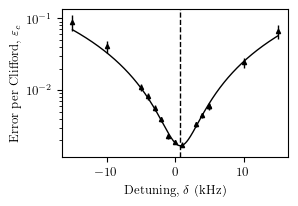

In [4]:
e_c = [t[0] for t in p1]
e_c_err = [t[1] for t in p1]
e_sp = [t[0] for t in p2]
e_sp_err = [t[1] for t in p2]

def detuning_model(x, e0, a, d):
    return e0 + a/3*(x - d) ** 2

popt, pcov = curve_fit(detuning_model, errs, e_c, sigma=e_c_err, absolute_sigma=True, p0=[0.01, 1.0, 0.0], bounds=([0.0, 0.0, -10.0], [1.0, 1_000_000, 10.0]))
print(f"Fitted e0: {popt[0]:.4f} ± {np.sqrt(pcov[0, 0]):.4f}")
print(f"Fitted detuning offset: 2*pi {popt[2]:.4f} ± {np.sqrt(pcov[2, 2]):.4f}")

fig_width = gs.get_fig_width()/2
fig_height = fig_width * 0.66
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.errorbar(errs, e_c, yerr=e_c_err, label="Data", color="k", fmt='^')
x_min = np.min(errs)
x_max = np.max(errs)
x_fit = np.linspace(x_min, x_max, 1000)
ax.plot(x_fit, detuning_model(x_fit, *popt), label="Fit", color="k", ls='-')
min_y = np.min(e_c)/1.5
max_y = np.max(e_c)*1.5
ax.set_ylim(min_y, max_y)
ax.vlines(popt[2], ymin=min_y, ymax=max_y, color="k", ls='--', label="Fitted detuning offset")
ax.set_xscale('linear')
ax.set_yscale('log')
ax.grid(None)
ax.set_xlabel("Detuning, $\\delta$ (kHz)")
ax.set_ylabel("Error per Clifford, $\\varepsilon_c$")
f_name = "..\\..\\pdf_figure\\ch4\\rb_detuning.pdf"
plt.savefig(f_name, bbox_inches='tight')

In [5]:
# fit decay for detuning = 1 kHz
rid = rids[np.argmin(abs(errs - 0.0))]
df, _, _ = m.rb_to_fits(date, rid, sim_outcomes)

Fitted e_c (3 points): 0.0019 ± 0.0001
Fitted e_sp (3 points): 0.0028 ± 0.0011
Fitted e_c: 0.0019 ± 0.0001
Fitted e_sp: 0.0030 ± 0.0016


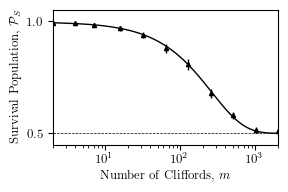

In [6]:
x, P_L, P_L_err, P_R, P_R_err = m.get_single_qubit_pops(df)
popt, pcov = curve_fit(
    m.single_qubit_model,
    x,
    P_L,
    sigma=P_L_err,
    p0=[0.01, 0.01],
)
# fit spam with first 3 points
popt3, pcov3 = curve_fit(
    m.single_qubit_model,
    x[:5],
    P_L[:5],
    sigma=P_L_err[:5],
    p0=[0.01, 0.01],
)
e_c = popt[0]
e_c_err = np.sqrt(pcov[0, 0])
e_sp = popt[1]
e_sp_err = np.sqrt(pcov[1, 1])

e_c3 = popt3[0]
e_c3_err = np.sqrt(pcov3[0, 0])
e_sp3 = popt3[1]
e_sp3_err = np.sqrt(pcov3[1, 1])
print(f"Fitted e_c (3 points): {e_c3:.4f} ± {e_c3_err:.4f}")
print(f"Fitted e_sp (3 points): {e_sp3:.4f} ± {e_sp3_err:.4f}")
print(f"Fitted e_c: {e_c:.4f} ± {e_c_err:.4f}")
print(f"Fitted e_sp: {e_sp:.4f} ± {e_sp_err:.4f}")
fig_width = gs.get_fig_width()/2
fig_height = fig_width * 0.6
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.errorbar(x, P_L, yerr=P_L_err, label="Data", color="k", fmt='^')
x_fit = np.linspace(np.min(x), np.max(x), 1000)
ax.plot(x_fit, m.single_qubit_model(x_fit, *popt), label="Fit", color="k", ls='-')
ax.grid(None)
ax.set_xscale('log')
ax.set_xlabel("Number of Cliffords, $m$")
ax.set_ylabel("Survival Population, $\\mathcal{P}_S$")
ax.set_ylim(0.45, 1.05)
ax.set_yticks([0.5, 1.0])
x_min = np.min(x)
x_max = np.max(x)
ax.set_xlim(x_min, x_max)
ax.hlines([0.5], xmin=np.min(x), xmax=np.max(x), color="k", ls='--', lw=0.5)



textstr = (
    f"SPAM error: {e_sp*1000:.0f}(1)$\\times 10$$^-$$^3$\n"
    + f"Clifford error: {e_c*1000:.1f}({e_c_err*10000:.0f})$\\times 10$$^-$$^3$"
)

f_name = "..\\..\\pdf_figure\\ch4\\rb_decay.pdf"
plt.savefig(f_name, bbox_inches="tight")

In [9]:
print(len(sim_outcomes))
F_2 = 1-e_c/2.17
F_2_err = e_c_err/2.17
print(f"F_2: {F_2:.5f} ± {F_2_err:.5f}")

550
F_2: 0.99913 ± 0.00002
